# 03 — Model Training & Evaluation
Train three models (Linear Regression → Random Forest → XGBoost), compare them,
visualize predictions, and save the best model to `models/`.

**Important:** We use a **time-based train/test split**, not random shuffling.
Shuffling would be data leakage — the model would see future data during training.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

sns.set_theme(style='whitegrid')
os.makedirs('../models', exist_ok=True)

## 1. Load Features & Define Split

In [11]:
df = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

FEATURE_COLS = [
    'aqi_lag1', 'aqi_lag2', 'aqi_lag3', 'aqi_lag7',
    'aqi_roll7', 'aqi_roll14', 'aqi_roll7_std',
    'day_of_week', 'month', 'is_weekend', 'wildfire_season',
]
# Add weather columns if they exist in the data
FEATURE_COLS += [c for c in ['tavg_c', 'tmax_c', 'tmin_c', 'prcp_mm', 'wind_ms']
                 if c in df.columns]

TARGET = 'target_aqi'

# Time-based split: last 20% of data as test set
split_idx = int(len(df) * 0.80)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
print(f'\nTrain period: {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Test period:  {test_df["date"].min().date()}  → {test_df["date"].max().date()}')

Training samples: 188
Test samples:     48

Train period: 2024-01-15 → 2024-07-20
Test period:  2024-07-21  → 2024-09-06


## 2. Baseline: Predict Yesterday's AQI
Always establish a naive baseline — if your model can't beat this, something's wrong.

In [12]:
baseline_preds = X_test['aqi_lag1']
baseline_mae   = mean_absolute_error(y_test, baseline_preds)
baseline_rmse  = np.sqrt(mean_squared_error(y_test, baseline_preds))
print(f'Naive baseline (predict yesterday):  MAE={baseline_mae:.2f}  RMSE={baseline_rmse:.2f}')

Naive baseline (predict yesterday):  MAE=11.25  RMSE=13.90


## 3. Train Three Models

In [13]:
models = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0)),
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'model':  model,
        'preds':  preds,
        'mae':    mean_absolute_error(y_test, preds),
        'rmse':   np.sqrt(mean_squared_error(y_test, preds)),
        'r2':     r2_score(y_test, preds),
    }
    print(f'{name:20s}  MAE={results[name]["mae"]:.2f}  '
          f'RMSE={results[name]["rmse"]:.2f}  R²={results[name]["r2"]:.3f}')

Ridge Regression      MAE=8.95  RMSE=10.40  R²=0.156
Random Forest         MAE=8.45  RMSE=10.24  R²=0.182
XGBoost               MAE=9.13  RMSE=10.91  R²=0.072


## 4. Compare Results

                     MAE    RMSE     R²
Ridge Regression   8.953  10.400  0.156
Random Forest      8.452  10.238  0.182
XGBoost            9.126  10.906  0.072
Naive Baseline    11.250  13.895 -0.507


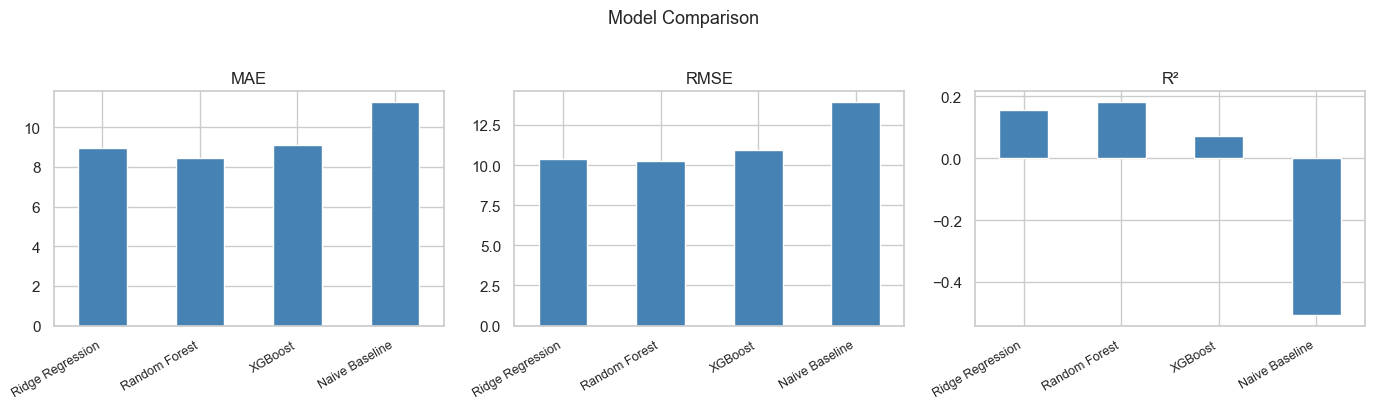

In [14]:
summary = pd.DataFrame({
    name: {'MAE': r['mae'], 'RMSE': r['rmse'], 'R²': r['r2']}
    for name, r in results.items()
}).T

# Add baseline row
summary.loc['Naive Baseline'] = {
    'MAE': baseline_mae, 'RMSE': baseline_rmse, 'R²': r2_score(y_test, baseline_preds)
}
print(summary.round(3))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    summary[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(metric)
    ax.set_xticklabels(summary.index, rotation=30, ha='right', fontsize=9)
plt.suptitle('Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Plot Predictions vs. Actuals (Best Model)

Best model: Random Forest


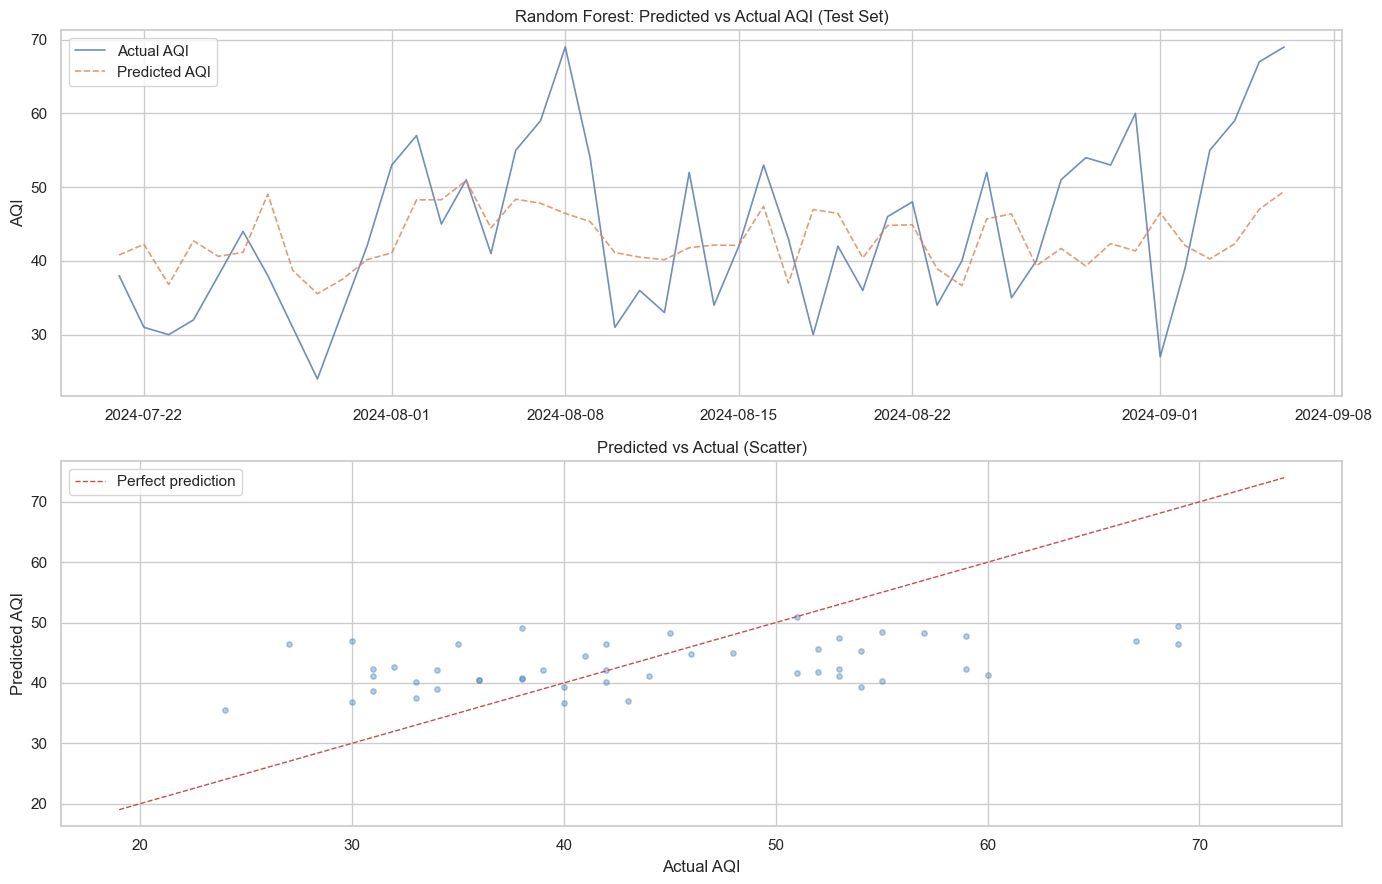

In [15]:
# Pick the model with lowest MAE
best_name = min(results, key=lambda k: results[k]['mae'])
best_preds = results[best_name]['preds']
print(f'Best model: {best_name}')

test_dates = test_df['date'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Time series: predicted vs actual
ax = axes[0]
ax.plot(test_dates, y_test.values, label='Actual AQI',    alpha=0.8, linewidth=1.2)
ax.plot(test_dates, best_preds,    label='Predicted AQI', alpha=0.8, linewidth=1.2, linestyle='--')
ax.set_title(f'{best_name}: Predicted vs Actual AQI (Test Set)')
ax.set_ylabel('AQI')
ax.legend()

# Scatter: predicted vs actual
ax2 = axes[1]
ax2.scatter(y_test, best_preds, alpha=0.4, s=15, color='steelblue')
lim = [min(y_test.min(), best_preds.min()) - 5,
       max(y_test.max(), best_preds.max()) + 5]
ax2.plot(lim, lim, 'r--', linewidth=1, label='Perfect prediction')
ax2.set_xlabel('Actual AQI')
ax2.set_ylabel('Predicted AQI')
ax2.set_title('Predicted vs Actual (Scatter)')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Feature Importance (Random Forest & XGBoost)

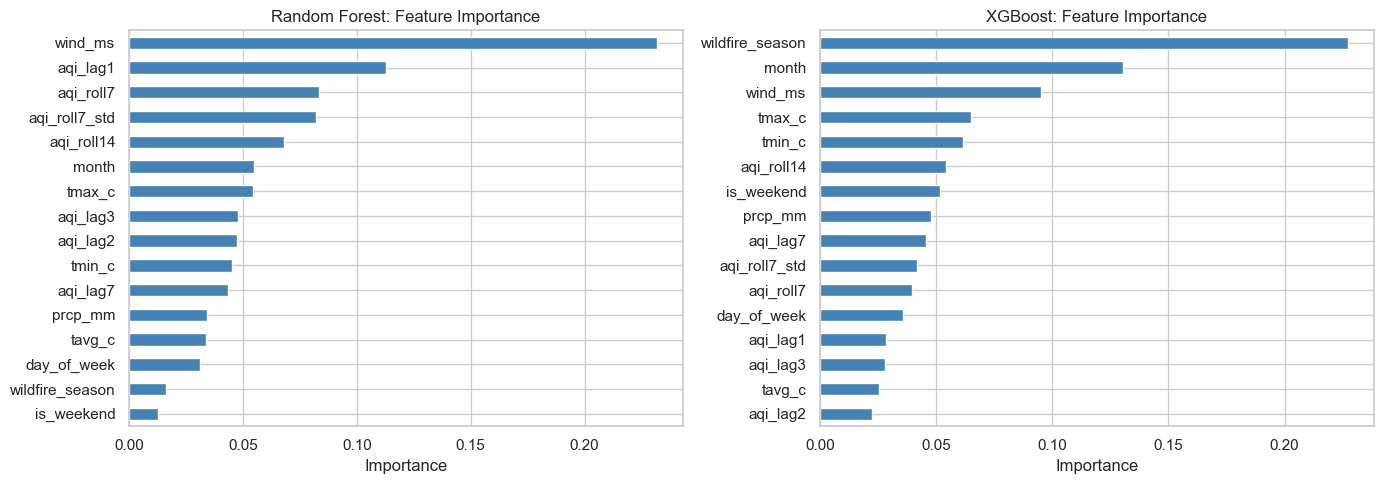


Top 5 features (Random Forest):
wind_ms          0.231556
aqi_lag1         0.112993
aqi_roll7        0.083343
aqi_roll7_std    0.082043
aqi_roll14       0.067941
dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model = results[model_name]['model']
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{model_name}: Feature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()
print('\nTop 5 features (Random Forest):')
rf_imp = pd.Series(results['Random Forest']['model'].feature_importances_,
                   index=FEATURE_COLS).sort_values(ascending=False)
print(rf_imp.head())

## 7. Save the Best Model

In [17]:
best_model = results[best_name]['model']
model_path = f'../models/best_model_{best_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_model, model_path)
print(f'Saved: {model_path}')

# Save feature list alongside model for inference
joblib.dump(FEATURE_COLS, '../models/feature_cols.pkl')
print('Saved: ../models/feature_cols.pkl')

Saved: ../models/best_model_random_forest.pkl
Saved: ../models/feature_cols.pkl


In [18]:
print(f'Best model: {best_name}')
print(f'MAE:  {results[best_name]["mae"]:.2f}')
print(f'RMSE: {results[best_name]["rmse"]:.2f}')
print(f'R²:   {results[best_name]["r2"]:.3f}')
print(f'\nBaseline MAE: {baseline_mae:.2f}')

Best model: Random Forest
MAE:  8.45
RMSE: 10.24
R²:   0.182

Baseline MAE: 11.25


In [19]:
print(FEATURE_COLS)

['aqi_lag1', 'aqi_lag2', 'aqi_lag3', 'aqi_lag7', 'aqi_roll7', 'aqi_roll14', 'aqi_roll7_std', 'day_of_week', 'month', 'is_weekend', 'wildfire_season', 'tavg_c', 'tmax_c', 'tmin_c', 'prcp_mm', 'wind_ms']


## 8. What to Try Next
- **Tune hyperparameters** with `GridSearchCV` or `optuna`
- **Add features**: humidity, pressure, smoke PM2.5 during wildfire season
- **Try LSTM**: `keras.layers.LSTM` for pure time-series forecasting
- **AQI category classification**: convert target to 'Good/Moderate/Unhealthy'
- **Streamlit app**: load the saved model and make a live prediction dashboard